This script is an example of loading in one of my data files, and getting the maps out.

In [1]:
using PhDProject

[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7](cache misses: wrong dep version loaded (1))
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a](cache misses: wrong dep version loaded (2))
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


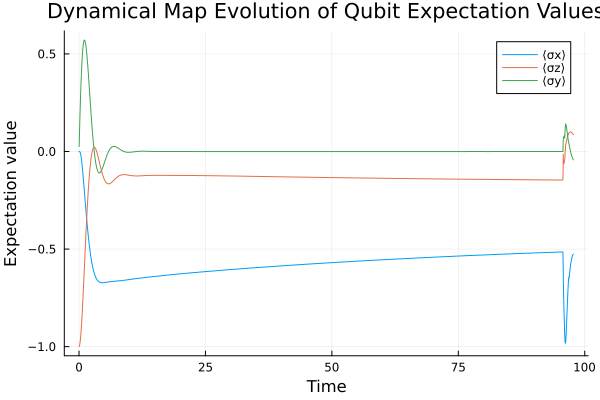

In [5]:
using JLD2, LinearAlgebra, Plots
alpha = 0.03 # coupling strength differentiates the files
filepath = "/Users/mf22297/OneDrive - University of Bristol/Documents/Fellowship/Data/"
filename = "SMB_QN_LBO_DynamicalMap_alpha=$(alpha)_wc=5.0_beta=1.0e7_s=0.3_epsilonsigmaz=0.0_delta=1.0_epsilon=1.0e-8_L=2500_dt=0.025_probBosonDim=1.0e-7_bathtype=exponential.jld2"

δt = 0.025

map_file = joinpath(filepath, filename)
maps = jldopen(map_file, "r"; iotype=IOStream) do f
    (
        times = Float64.(f["times"]),
        dynmaps = f["dynamicalmaps"],
    )
end

vecρ(ρ) = vec(ρ)
matρ(v) = reshape(v, 2, 2)
expect_denmat(ρ, X) = real(tr(ρ * X))

σx = ComplexF64[0 1; 1 0]
σy = ComplexF64[0 -im; im 0]
σz = ComplexF64[1 0; 0 -1]

function applyMap(dyn_maps, step, rho_init)
    Map_t = Matrix{ComplexF64}(dyn_maps[:,:,step])
    return matρ(Map_t * vecρ(rho_init))
end

times, dyn_maps = maps.times, maps.dynmaps
vectorised_maps = complex(zeros(16,length(dyn_maps[1,1,:])))
[vectorised_maps[:,i] = vec(dyn_maps[:,:,i]) for i =1:length(dyn_maps[1,1,:])]

reshape(dyn_maps,16,length(dyn_maps[1,1,:]))
rho_init = [0 0.0; 0.0 1] # initial state of qubit |0><0|
#rho_init = [0.5 0; 0 0.5] # initial state of qubit |0><0|

sx = []
sy = []
sz = []

steps = 1:length(times)
for n in steps
    dynmap = applyMap(dyn_maps, n, rho_init)
    push!(sx, expect_denmat(dynmap, σx))
    push!(sy, expect_denmat(dynmap, σy))
    push!(sz, expect_denmat(dynmap, σz))
end

p = plot(times, sx, label="⟨σx⟩", xlabel="Time", ylabel="Expectation value", title="Dynamical Map Evolution of Qubit Expectation Values")
plot!(p, times, sz, label="⟨σz⟩")
plot!(p, times, sy, label="⟨σy⟩")
display(p)



In [13]:
Λ = dyn_maps[:,:,1000]
F = eigen(Λ).vectors
D = diagm(eigen(Λ).values)
get_inv(F)*Λ*F

4×4 Matrix{ComplexF64}:
  -5.64296e-5+3.22362e-18im  …  -1.19685e-16+1.18888e-16im
  2.05772e-17-1.0305e-17im       2.07116e-16-1.49396e-17im
  5.55112e-17-2.22025e-17im     -6.00371e-17-5.98387e-17im
 -3.09189e-16+7.07407e-18im          1.00002+5.64932e-21im

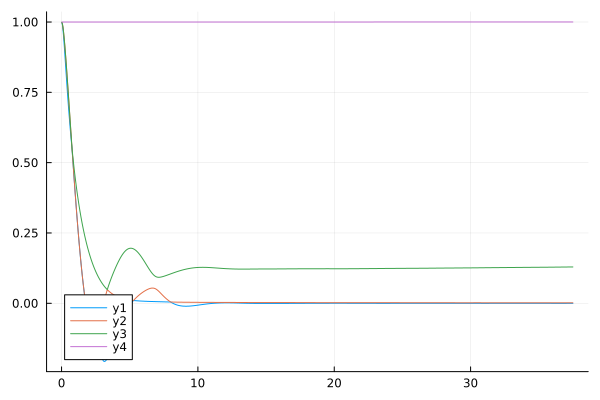

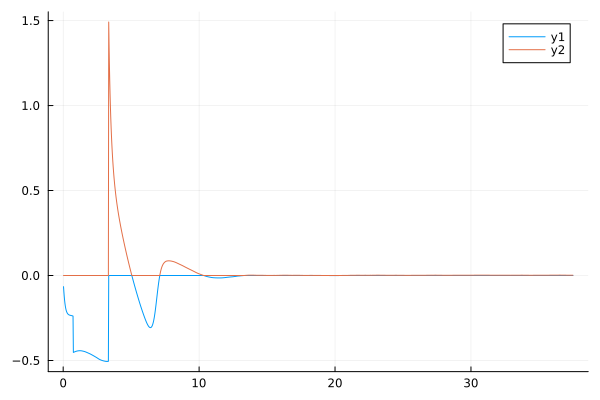

In [ ]:
propagators = complex(zeros(2,2,length(times)-2))
for i=1:length(times)-2
    Λs = [dyn_maps[:,:,i],dyn_maps[:,:,i+1],dyn_maps[:,:,i+2]]
    Λ = Λs[2]
    dΛτdt = compute_dΛdt(Λs,δt) 
    D = diagm(eigen(Λ).values)
    F = eigen(Λ).vectors
    dΛτdt = (get_inv(F)*dΛτdt*F)[3:4,3:4]
    L = dΛτdt*get_inv(D[3:4,3:4])
    L = F[3:4,3:4]*L*get_inv(F)[3:4,3:4]
    propagators[:,:,i] = L
end


spectra_Λ = complex(zeros(4,length(times)))
spectra_L = complex(zeros(2,length(times)-2))

[spectra_Λ[:,i] .= eigen(dyn_maps[:,:,i]).values for i=1:length(times)]
[spectra_L[:,i] .= eigen(propagators[:,:,i]).values for i=1:(length(times)-2)]

display(Plots.plot(times[1:1500],real.(transpose(spectra_Λ[:,1:1500]))))
#Plots.savefig("Real part of bubble spectra.pdf")
display(Plots.plot(times[1:1500],real.(transpose(spectra_L[:,1:1500]))))#ylim=(-0.01,0.01)))



In [4]:
spectra = complex(zeros(4,10000))
for i=1:length(dyn_maps[1,1,:])
    spectra[:,i] .= eigen(dyn_maps[:,:,i]).values
end


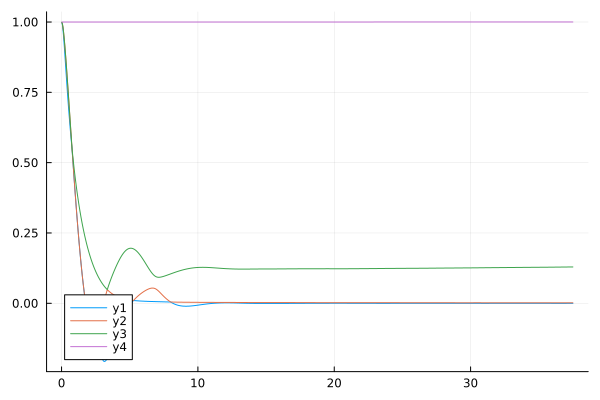

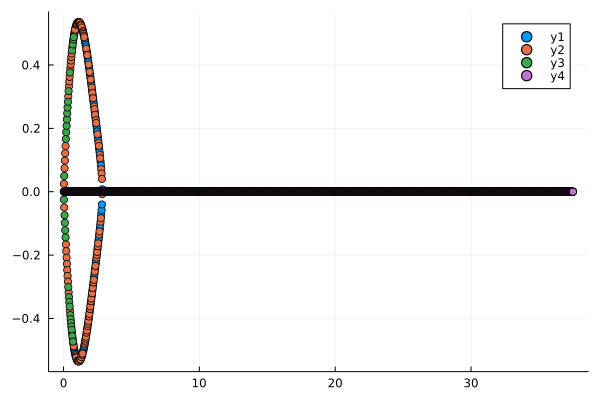

In [5]:
display(Plots.plot(times[1:1500],real.(transpose(spectra[:,1:1500]))))
#Plots.savefig("Real part of bubble spectra.pdf")
Plots.scatter(times[1:1500],imag.(transpose(spectra[:,1:1500])))
#Plots.savefig("Imaginary part of bubble spectra.pdf")

In [112]:
values = eigen(dyn_maps[:,:,1500]).values
vectors = eigen(dyn_maps[:,:,1500]).vectors
persistent_decay_mode = reshape(vectors[:,3],2,2)
steady_state = reshape(vectors[:,4],2,2)

2×2 Matrix{ComplexF64}:
  0.608618+5.94366e-17im  -0.359978-2.89534e-15im
 -0.359978+2.87263e-15im   0.608618+0.0im

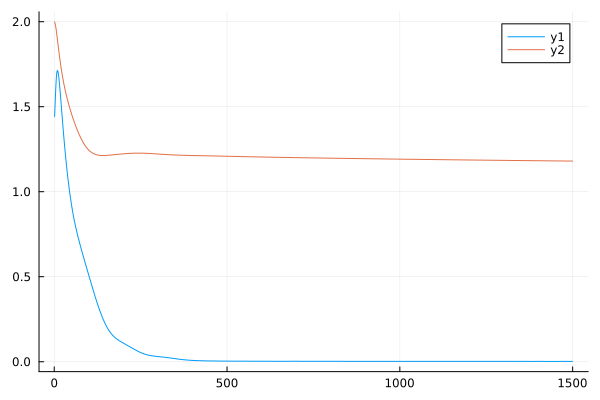

In [6]:
dt = 0.025
dΛdt = complex(zeros(4,4,1499))
[dΛdt[:,:,i]=(dyn_maps[:,:,i+1]-dyn_maps[:,:,i])/dt for i =1:1499]
dΛdt_norm = [norm(dΛdt[:,:,i]) for i =1:1499]
dyn_maps_norm = [norm(dyn_maps[:,:,i]) for i =1:1500]
Plots.plot(1:1499,dΛdt_norm)
Plots.plot!(1:1500,dyn_maps_norm)
